#Análisis de variables

In [1]:
pip install matplotlib-scalebar

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.api import GLM, families
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
from matplotlib_scalebar.scalebar import ScaleBar

In [3]:
#variables
variables = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="variables")
variables.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu,geometry
0,Aguas Frias,ALTAVISTA,32888.553485,1.308501e+07,27,13.085013,2.063429,3.472526,1.156317,0.332990,29.564836,5.118618,2.471720,0.000000,"MULTIPOLYGON (((4710927.69 2248217.723, 471092..."
1,Aldea Pablo VI,POPULAR,1548.983811,5.560887e+04,3,0.055609,53.948225,0.014758,0.128480,8.706006,19.185280,64.712141,0.000000,100.000000,"MULTIPOLYGON (((4718950.025 2253647.826, 47189..."
2,Alejandro Echavarría,BUENOS AIRES,3873.259719,3.600769e+05,15,0.360077,41.657774,0.095558,0.642398,6.722609,11.555980,62.817569,88.785759,11.039618,"MULTIPOLYGON (((4718344.177 2248210.468, 47183..."
3,Alejandría,EL POBLADO,2783.340991,4.314227e+05,8,0.431423,18.543298,0.114492,0.342612,2.992463,10.526186,46.877115,100.000000,0.000000,"MULTIPOLYGON (((4715894.965 2243436.368, 47158..."
4,Alfonso López,CASTILLA,3360.868167,3.679919e+05,2,0.367992,5.434902,0.097658,0.085653,0.877069,9.505469,73.895347,88.106810,0.000000,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [4]:
gdf = variables

In [ ]:
gdf.describe()

,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu
count,348.000000,3.480000e+02,348.00000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,4884.195679,1.081193e+06,6.70977,1.082803,19.541674,0.286929,0.287356,3.153578,14.382395,55.448110,50.511041,9.272696
std,5357.950987,2.492141e+06,8.88117,2.492025,28.733296,0.661369,0.380350,4.636895,8.292821,28.882262,45.610183,26.981616
min,257.367765,2.754026e+03,0.00000,0.002754,0.000000,0.000731,0.000000,0.000000,1.683571,0.000000,0.000000,0.000000
25%,2510.848930,2.343425e+05,1.00000,0.234343,0.631789,0.062190,0.042827,0.101956,7.902588,32.525095,0.000000,0.000000
50%,3217.685757,3.705293e+05,3.50000,0.370529,8.709662,0.098332,0.149893,1.405540,13.408251,64.017833,53.665414,0.000000
75%,4357.636530,6.207013e+05,8.00000,0.621647,23.926065,0.164723,0.342612,3.861118,19.760685,80.164120,100.000000,0.000000
max,38723.006984,1.710786e+07,62.00000,17.107858,163.893433,4.540116,2.655246,26.448640,36.812111,95.820104,100.000000,100.000000


In [5]:
n_barrios = len(gdf)

n_ceros = (gdf["Movimientos"] == 0).sum()

porcentaje = 100 * n_ceros / n_barrios

print(f"Barrios: {n_barrios}")
print(f"Barrios sin movimientos: {n_ceros}")
print(f"Porcentaje: {porcentaje:.1f}%")

Barrios: 348
Barrios sin movimientos: 70
Porcentaje: 20.1%


In [6]:
from scipy import stats

y = gdf["Movimientos"].astype(int).values

media = y.mean()
varianza = y.var(ddof=1)
idisp = varianza / media

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Índice de dispersión: {idisp:.2f}")

Media: 6.71
Varianza: 78.88
Índice de dispersión: 11.76


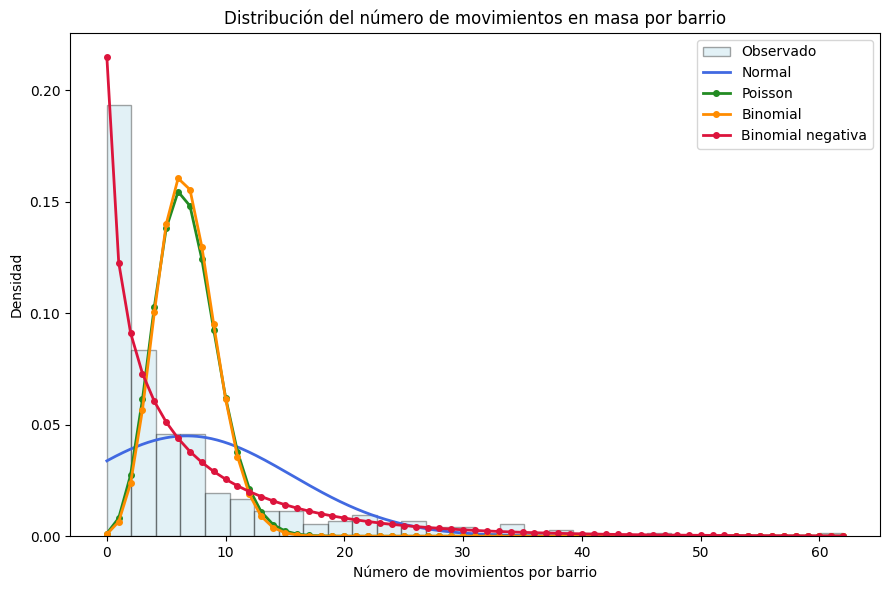

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Histograma
ax.hist(
    y,
    bins=30,
    density=True,
    alpha=0.35,
    color="lightblue",
    edgecolor="black",
    label="Observado")

x = np.linspace(y.min(), y.max(), 500)

k = np.arange(y.min(), y.max() + 1)

# D. Normal
mu, sigma = stats.norm.fit(y)

ax.plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    color="royalblue",
    linewidth=2,
    label="Normal")

# D. Poisson
lam = y.mean()

ax.plot(
    k,
    stats.poisson.pmf(k, lam),
    "o-",
    color="forestgreen",
    linewidth=2,
    markersize=4,
    label="Poisson")

# D. Binomial
n_binom = int(np.ceil(y.max() * 1.2))
p_binom = media / n_binom

ax.plot(
    k,
    stats.binom.pmf(k, n_binom, p_binom),
    "o-",
    color="darkorange",
    linewidth=2,
    markersize=4,
    label="Binomial")

# D. Binomial negativa

if varianza > media:
    p_nb = media / varianza
    r_nb = media * p_nb / (1 - p_nb)

    ax.plot(
        k,
        stats.nbinom.pmf(k, r_nb, p_nb),
        "o-",
        color="crimson",
        linewidth=2,
        markersize=4,
        label="Binomial negativa")

ax.set_xlabel("Número de movimientos por barrio")
ax.set_ylabel("Densidad")
ax.set_title("Distribución del número de movimientos en masa por barrio")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
gdf[["nombre_bar",
        "Area_km2",
        "Porc_Artificial",
        "Porc_Qca",
        "Porc_TPu",
        "Pend_mean" ]].round(2)

,nombre_bar,Area_km2,Porc_Artificial,Porc_Qca,Porc_TPu,Pend_mean
0,Aguas Frias,13.09,5.12,2.47,0.00,29.56
1,Aldea Pablo VI,0.06,64.71,0.00,100.00,19.19
2,Alejandro Echavarría,0.36,62.82,88.79,11.04,11.56
3,Alejandría,0.43,46.88,100.00,0.00,10.53
4,Alfonso López,0.37,73.90,88.11,0.00,9.51
...,...,...,...,...,...,...
343,Volcana Guayabal,9.28,3.32,0.00,0.00,33.81
344,Yarumalito,14.83,2.36,0.02,0.00,32.26
345,Yolombo,4.64,4.69,4.34,0.00,21.16
346,Área de Expansión Pajarito,2.40,29.74,100.00,0.00,18.23


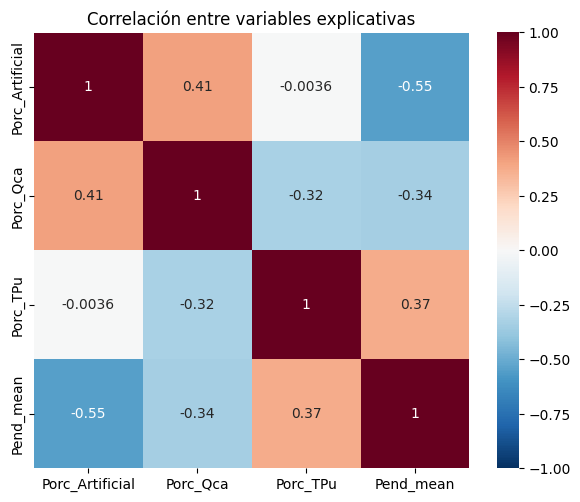

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Porc_Artificial","Porc_Qca", "Porc_TPu", "Pend_mean"]

corr = gdf[variables].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True)

plt.title("Correlación entre variables explicativas")
plt.tight_layout()
plt.show()

#GML

**Mi variable dependiente**

Y= Número de movimientos en masa esperados por barrio en Medellín

**Mis variables condicionantes**
Estas las defino teniendo en cuenta los análisis anteriores, ya vi que las unidades geológicas que mas se asocian a los movimientos en masa de Medellín son los depósitos y las Dunitas y en términos de coberturas, la más afectada es el territorio artificializado por lo que:

Offset = Área del barrio (Area_km2)

X1 = % de Territorios Artificializados

X2 = % de depósitos aluviales/coluviales (Q-ca)

X3 = % de Dunitas (T-Pu)

X4 = Pendiente media de la cuenca

##Poisson

In [7]:
import statsmodels.api as sm

import statsmodels.formula.api as smf

y = gdf["Movimientos"]
var = ["Porc_Artificial", "Porc_Qca", "Porc_TPu", "Pend_mean"]
exposure = np.log(gdf["Area_km2"])

st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

X = sm.add_constant(X_scaled)

poisson_model_offset = GLM(y, X, family=families.Poisson(), offset=exposure).fit()

print(poisson_model_offset.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Movimientos   No. Observations:                  348
Model:                            GLM   Df Residuals:                      343
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1652.3
Date:                Wed, 15 Jul 2026   Deviance:                       2326.6
Time:                        15:55:56   Pearson chi2:                 3.67e+03
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1269      0.025     83.710      0.0

In [8]:
poisson_model_offset.aic

np.float64(3314.6039091854072)

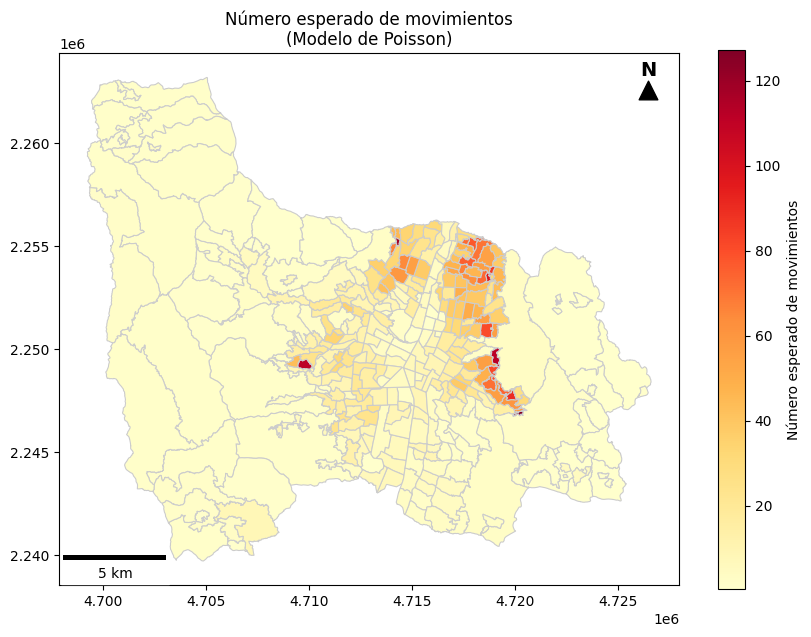

In [23]:
y_pred_freq_offset = poisson_model_offset.predict(X)

gdf['Prediccion_Menm'] = y_pred_freq_offset

gdf["Error_P"] = ((gdf["Movimientos"] - gdf["Prediccion_Menm"]))

fig, ax = plt.subplots(figsize=(10, 7))

gdf.plot(column='Prediccion_Menm', cmap='YlOrRd', linewidth=0.8, edgecolor='0.8', legend=True, legend_kwds={"label":"Número esperado de movimientos"},
         ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title('Número esperado de movimientos\n(Modelo de Poisson)')

plt.show()

In [ ]:
gdf['Prediccion_Menm'] = poisson_model_offset.predict(X, offset=exposure)
gdf["Error_P"] = gdf["Movimientos"] - gdf['Prediccion_Menm']

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(gdf["Movimientos"], gdf['Prediccion_Menm'])
rmse = np.sqrt(mean_squared_error(gdf["Movimientos"], gdf['Prediccion_Menm']))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 4.96
RMSE: 7.64


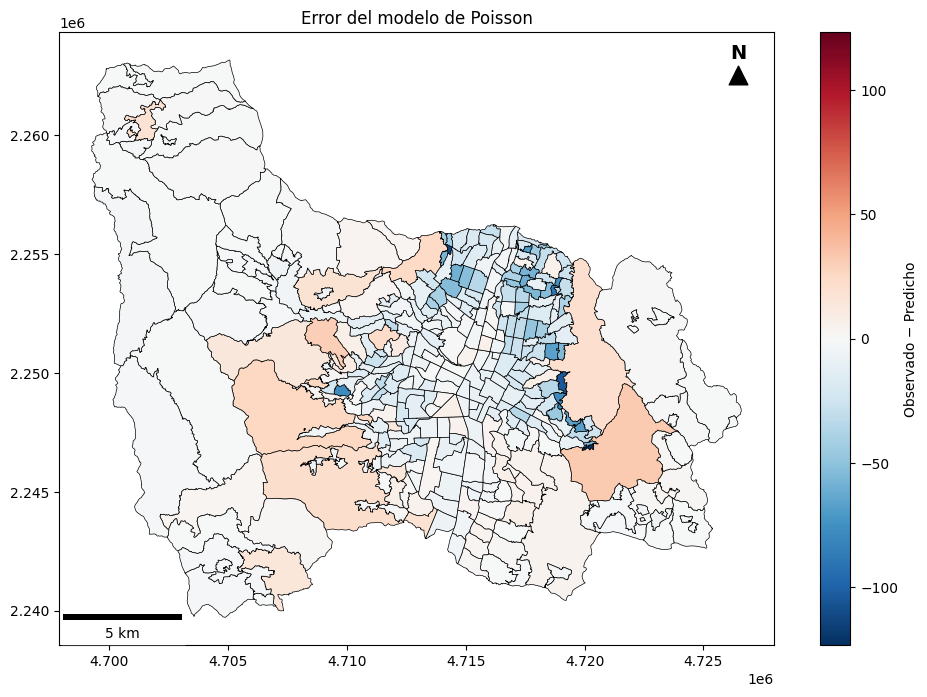

In [25]:
from matplotlib.colors import TwoSlopeNorm
v = np.abs(gdf["Error_P"]).max()

fig, ax = plt.subplots(figsize=(10,7))

gdf.plot(
    column="Error_P",
    cmap="RdBu_r",
    linewidth=0.5,
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v),
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label":"Observado − Predicho"
    },
    ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Error del modelo de Poisson")

plt.tight_layout()
plt.show()

##Binomial negativa

In [29]:
y = gdf["Movimientos"]

var = ["Porc_Artificial", "Porc_Qca", "Porc_TPu", "Pend_mean"]

offset = np.log(gdf["Area_km2"])

st = StandardScaler()

X_scaled = st.fit_transform(gdf[var])
X = sm.add_constant(X_scaled)

modelo_nb = GLM(y, X,
    family=families.NegativeBinomial(),
    offset=offset).fit()

print(modelo_nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Movimientos   No. Observations:                  348
Model:                            GLM   Df Residuals:                      343
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -979.01
Date:                Wed, 15 Jul 2026   Deviance:                       422.29
Time:                        16:08:50   Pearson chi2:                     491.
No. Iterations:                    13   Pseudo R-squ. (CS):             0.5505
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4520      0.061     40.434      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [30]:
modelo_nb.aic

np.float64(1968.0268379298586)

In [31]:
gdf["Pred_Mov"] = modelo_nb.predict(X, offset=offset)
gdf["Error_bn"] = gdf["Movimientos"] - gdf["Pred_Mov"]

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(gdf["Movimientos"], gdf["Pred_Mov"])
rmse = np.sqrt(mean_squared_error(gdf["Movimientos"], gdf["Pred_Mov"]))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 6.40
RMSE: 11.50


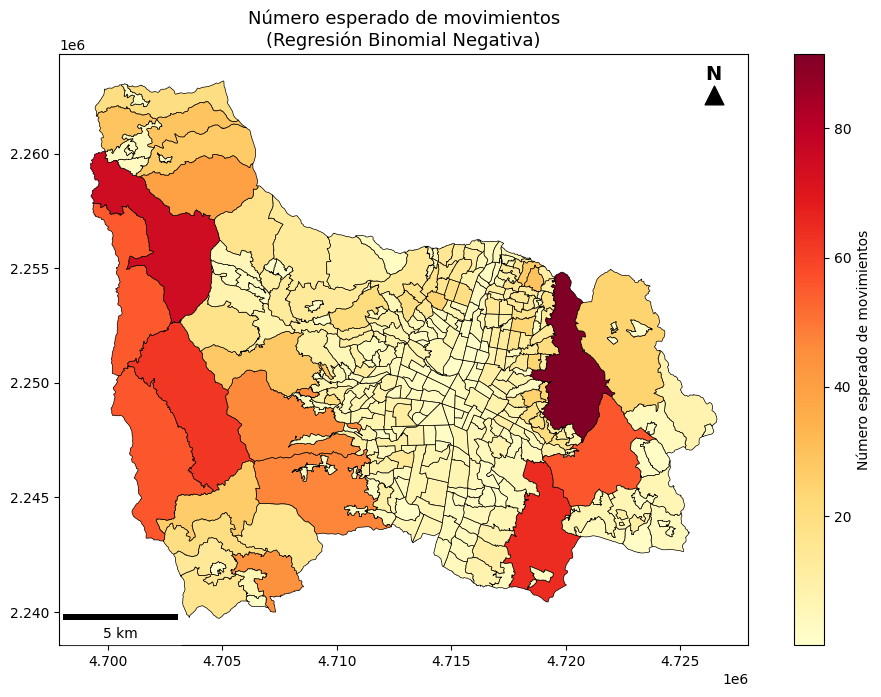

In [32]:
fig, ax = plt.subplots(figsize=(10,7))

gdf.plot(
    column="Pred_Mov",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label":"Número esperado de movimientos"},
    ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Número esperado de movimientos\n(Regresión Binomial Negativa)",
    fontsize=13)


plt.tight_layout()
plt.show()

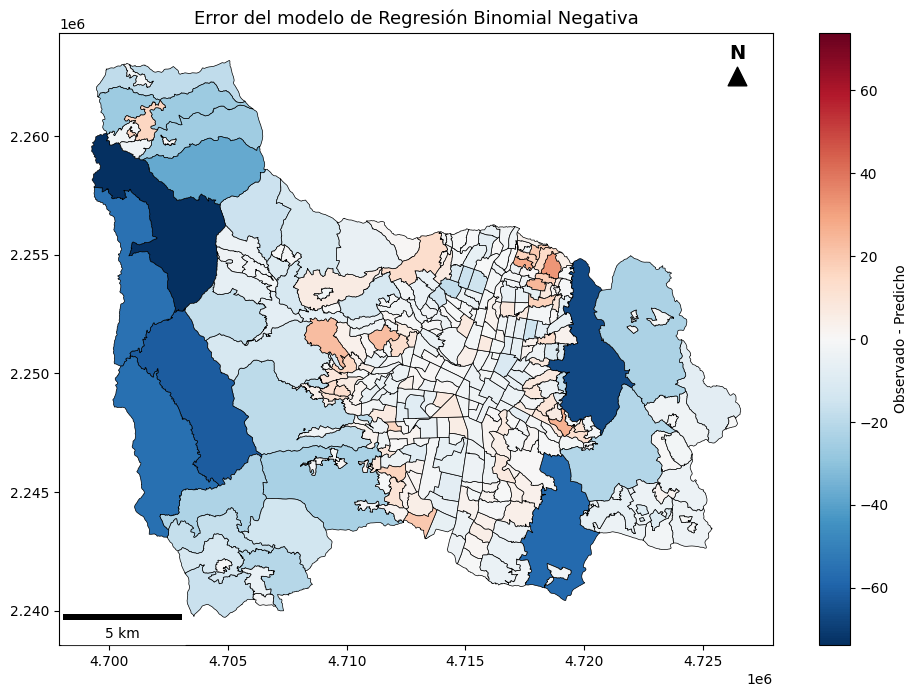

In [33]:
from matplotlib.colors import TwoSlopeNorm
v = np.abs(gdf["Error_bn"]).max()

fig, ax = plt.subplots(figsize=(10,7))

gdf.plot(
    column="Error_bn",
    cmap="RdBu_r",
    linewidth=0.5,
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v),
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label":"Observado - Predicho"},
    ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Error del modelo de Regresión Binomial Negativa",
    fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
from libpysal import weights
knn5 = weights.KNN.from_dataframe(gdf, k=5)
knn5.transform = "r"

In [ ]:
from esda.moran import Moran
mi_res = Moran(
    gdf["Error_bn"],
    knn5)

print(mi_res.I)
print(mi_res.p_sim)

0.27828697331649443
0.001


In [ ]:
gdf["Residuo"] = ( gdf["Movimientos"] - gdf["Pred_Mov"])
sigma = gdf["Residuo"].std()

print(f"Desviación estándar: {sigma:.2f}")

Desviación estándar: 11.34


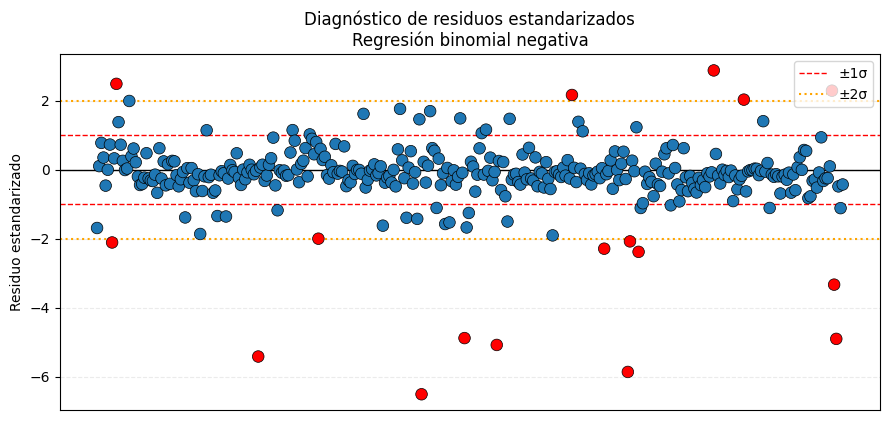

In [ ]:
gdf["Residuo"] = gdf["Movimientos"] - gdf["Pred_Mov"]
gdf["Residuo_std"] = gdf["Residuo"] / gdf["Residuo"].std()

gdf["Atipico"] = np.abs(gdf["Residuo_std"]) > 2

fig, ax = plt.subplots(figsize=(9, 4.5))

colores = np.where(gdf["Atipico"], "red", "#1f77b4")

ax.scatter(
    gdf["nombre_bar"],
    gdf["Residuo_std"],
    s=70,
    c=colores,
    edgecolor="black",
    linewidth=0.5,
    zorder=3)


ax.axhline(0, color="black", linewidth=1)
ax.axhline(1, color="red", linestyle="--", linewidth=1, label="±1σ")
ax.axhline(-1, color="red", linestyle="--", linewidth=1)
ax.axhline(2, color="orange", linestyle=":", linewidth=1.5, label="±2σ")
ax.axhline(-2, color="orange", linestyle=":", linewidth=1.5)


ax.set_ylabel("Residuo estandarizado")
ax.set_xlabel(" ")
ax.set_title("Diagnóstico de residuos estandarizados\nRegresión binomial negativa")

plt.xticks(rotation=90)
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.xticks([])
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np


def resumen_significancia(modelo, variables):

    p = modelo.pvalues.iloc[1:]   # excluye la constante

    sig = []
    marg = []

    for v, pv in zip(variables, p):

        if pv < 0.05:
            sig.append(v)

        elif pv < 0.10:
            marg.append(v)

    return (
        ", ".join(sig) if sig else "Ninguna",
        ", ".join(marg) if marg else "-"
    )

sig_pois, marg_pois = resumen_significancia(poisson_model_offset, var)
sig_nb, marg_nb = resumen_significancia(modelo_nb, var)


comparacion = pd.DataFrame({

    "Indicador":[
        "Log-Likelihood",
        "AIC",
        "Deviance",
        "Pearson χ²",
        "Pearson χ² / gl",
        "Pseudo R² (CS)",
        "Variables significativas",
        "Variables marginales"
    ],

    "Poisson":[

        poisson_model_offset.llf,
        poisson_model_offset.aic,
        poisson_model_offset.deviance,
        poisson_model_offset.pearson_chi2,
        poisson_model_offset.pearson_chi2/poisson_model_offset.df_resid,
        poisson_model_offset.pseudo_rsquared(kind="cs"),
        sig_pois,
        marg_pois
    ],

    "Binomial Negativa":[

        modelo_nb.llf,
        modelo_nb.aic,
        modelo_nb.deviance,
        modelo_nb.pearson_chi2,
        modelo_nb.pearson_chi2/modelo_nb.df_resid,
        modelo_nb.pseudo_rsquared(kind="cs"),
        sig_nb,
        marg_nb
    ]

})

comparacion

,Indicador,Poisson,Binomial Negativa
0,Log-Likelihood,-1652.301955,-979.013419
1,AIC,3314.603909,1968.026838
2,Deviance,2326.640668,422.293881
3,Pearson χ²,3673.731478,490.515569
4,Pearson χ² / gl,10.710587,1.430075
5,Pseudo R² (CS),0.999998,0.550468
6,Variables significativas,"Porc_Artificial, Porc_Qca, Porc_TPu, Pend_mean","Porc_Artificial, Porc_Qca, Porc_TPu, Pend_mean"
7,Variables marginales,-,-


In [ ]:
residuos_estandarizados = gdf["Residuo_std"]

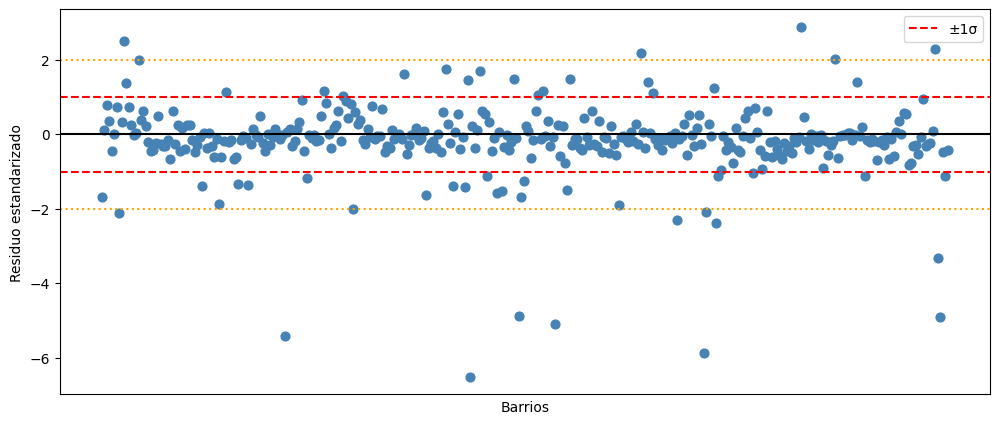

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))

ax.scatter(
    np.arange(len(gdf)),
    residuos_estandarizados,
    s=40,
    color="steelblue"
)

ax.axhline(0, color="black")
ax.axhline(1, color="red", ls="--", label="±1σ")
ax.axhline(-1, color="red", ls="--")
ax.axhline(2, color="orange", ls=":")
ax.axhline(-2, color="orange", ls=":")

ax.set_xlabel("Barrios")
ax.set_ylabel("Residuo estandarizado")
ax.set_xticks([])

plt.legend()
plt.show()

##Cluster espacial

In [35]:
variables = ["Porc_Artificial", "Porc_Qca", "Porc_TPu", "Pend_mean"]

In [ ]:
var = ["Movimientos","Pend_mean"]

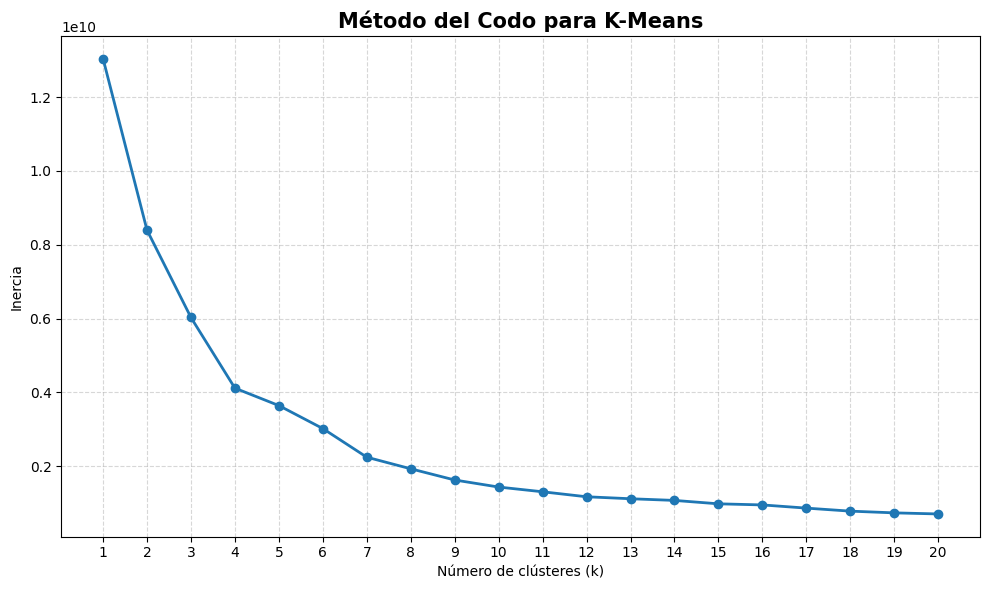

In [36]:
from sklearn.cluster import KMeans, AgglomerativeClustering
coordenadas = np.column_stack((
    gdf.geometry.centroid.x,
    gdf.geometry.centroid.y))

def elbow_method_espacial(datos, max_clusters=20):
    inertia = []

    for k in range(1, max_clusters + 1):

        kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
        kmeans.fit(datos)
        inertia.append(kmeans.inertia_)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, max_clusters + 1), inertia, marker="o", linewidth=2)

    ax.set_title("Método del Codo para K-Means", fontsize=15, fontweight="bold")
    ax.set_xlabel("Número de clústeres (k)")
    ax.set_ylabel("Inercia")
    ax.set_xticks(range(1, max_clusters + 1))
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

elbow_method_espacial(coordenadas, max_clusters=20)

In [37]:
from sklearn import cluster
kmeans4 = cluster.KMeans(n_clusters=4)
k4cls = kmeans4.fit(gdf[variables]);
k4cls.labels_

array([2, 3, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0,
       0, 0, 1, 1, 0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 3, 0, 0, 1, 2, 1, 2,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 0, 2, 1, 3, 2, 1, 0, 0, 0, 1, 2,
       2, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 1, 2, 0, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 3,
       1, 0, 1, 2, 1, 0, 3, 1, 0, 1, 3, 2, 0, 2, 3, 0, 0, 2, 0, 2, 0, 0,
       1, 0, 0, 0, 2, 2, 0, 1, 2, 0, 2, 0, 0, 0, 0, 0, 3, 2, 2, 2, 0, 0,
       0, 0, 0, 3, 0, 1, 2, 2, 0, 1, 3, 0, 2, 0, 0, 3, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 3, 0, 0, 0, 0, 0, 2, 0, 2, 1, 0, 0,
       0, 1, 0, 0, 2, 3, 2, 0, 0, 0, 2, 2, 0, 0, 0, 3, 1, 0, 1, 0, 0, 0,
       0, 1, 2, 2, 3, 3, 0, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0,
       0, 3, 3, 1, 0, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2,

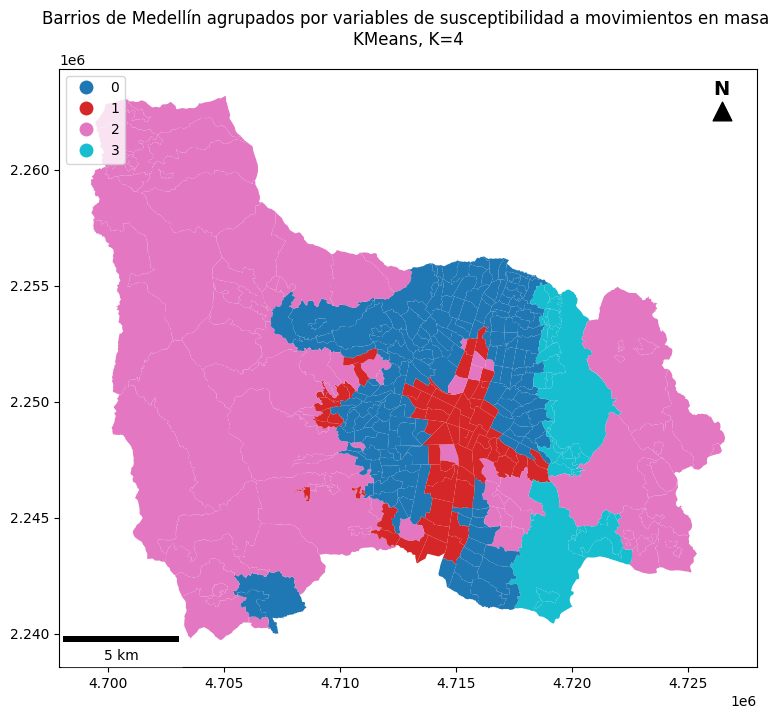

In [38]:
import matplotlib.pyplot as plt

gdf['k4cls'] = k4cls.labels_

f, ax = plt.subplots(1, figsize=(9, 9))

gdf.plot(column='k4cls', categorical=True, legend=True, linewidth=0, ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

plt.title('Barrios de Medellín agrupados por variables de susceptibilidad a movimientos en masa \nKMeans, K=4')
plt.show()

In [39]:
k4means = gdf.groupby('k4cls')[variables].mean()

k4means.T

k4cls,0,1,2,3
Porc_Artificial,67.032184,72.646114,15.639844,56.200836
Porc_Qca,93.963423,7.886604,5.491243,3.653856
Porc_TPu,1.149217,0.194951,2.155870,94.734685
Pend_mean,11.607898,8.737481,21.526292,23.701506


In [40]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from libpysal.weights import Queen, KNN


In [48]:
w = KNN.from_dataframe(gdf, k=5)

In [50]:
np.random.seed(123456)
model = AgglomerativeClustering(linkage='ward',connectivity=w.sparse,n_clusters=4)
model.fit(gdf[variables])

AgglomerativeClustering(connectivity=<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1740 stored elements and shape (348, 348)>,
                        n_clusters=4)

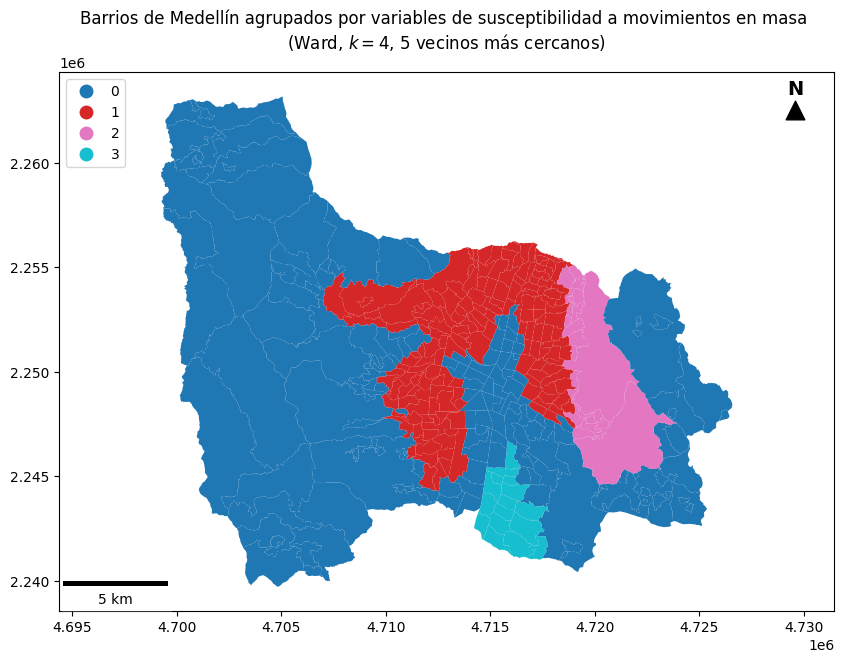

In [51]:
gdf['wardwkn5'] = model.labels_

f, ax = plt.subplots(1, figsize=(10,7))

gdf.plot(column='wardwkn5', categorical=True, legend=True, linewidth=0, ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

plt.axis('equal')
plt.title('Barrios de Medellín agrupados por variables de susceptibilidad a movimientos en masa \n(Ward, $k=4$, 5 vecinos más cercanos)')
plt.show()

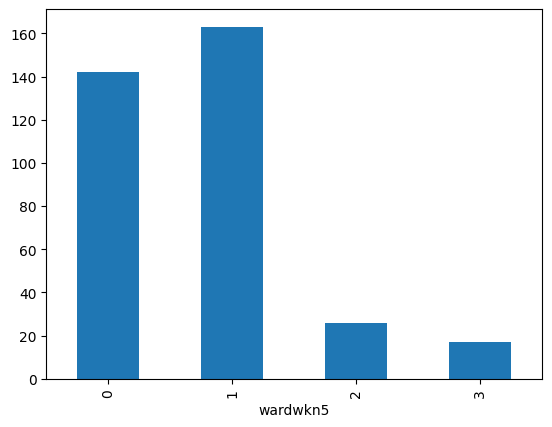

In [62]:
k4sizes = gdf.groupby('wardwkn5').size()
_ = k4sizes.plot.bar()

In [63]:
k4sk = gdf.groupby('wardwkn5')[variables].mean()

k4sk.T

wardwkn5,0,1,2,3
Porc_Artificial,39.665133,69.799935,60.108428,42.546172
Porc_Qca,6.257070,92.911902,2.533321,86.990119
Porc_TPu,3.312306,1.627383,95.793921,0.037980
Pend_mean,16.003482,11.658101,25.066066,10.623005


In [65]:
from sklearn.preprocessing import StandardScaler
cat = gdf
cat_std= StandardScaler().fit_transform(cat[variables])

In [55]:
from scipy.cluster.hierarchy import dendrogram,linkage

Z=linkage(cat_std,method='ward',metric='euclidean')

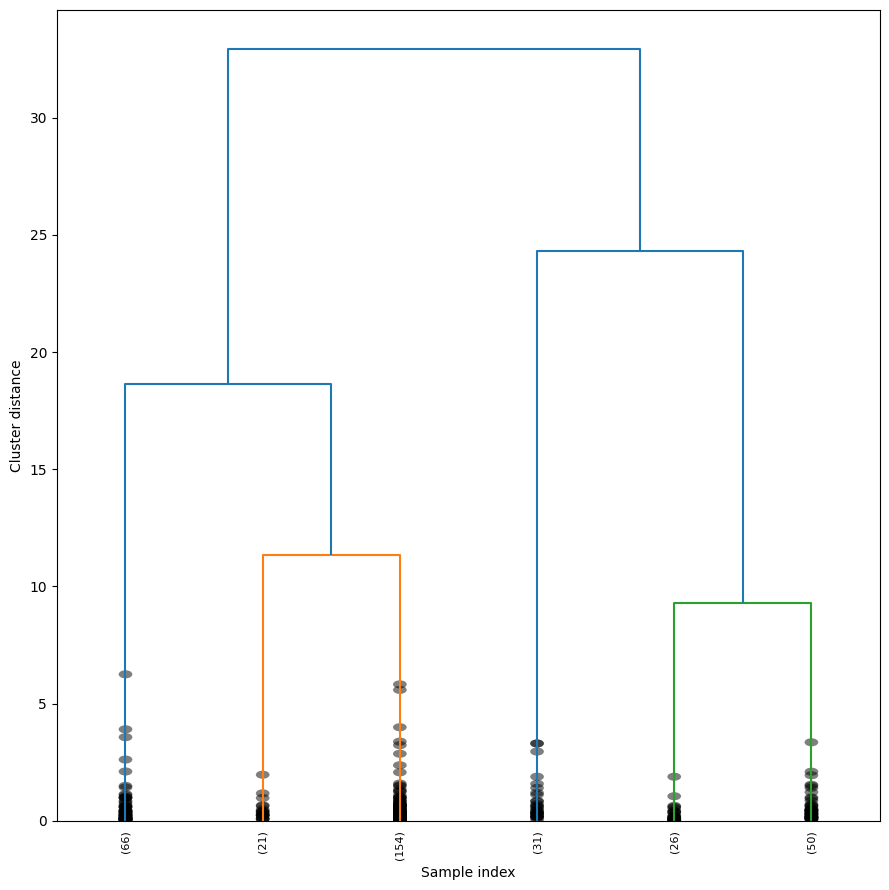

In [56]:
plt.figure(figsize=(9,9))
plt.xlabel('Sample index')
plt.ylabel('Cluster distance');

dendrogram(Z,leaf_rotation=90.,leaf_font_size=8,color_threshold=0.2*83,truncate_mode='lastp',p=6,show_leaf_counts=True,show_contracted=True)

plt.tight_layout()

In [66]:
from sklearn import cluster

k4cls = cluster.KMeans(n_clusters=4).fit(cat_std)
cat['kmeans4'] = k4cls.labels_

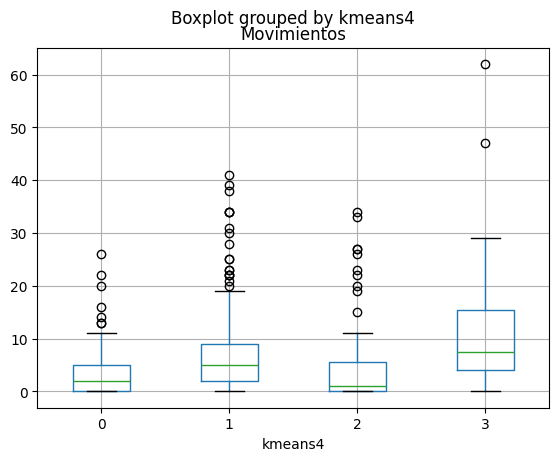

In [67]:
f,ax=plt.subplots()
cat.boxplot(column=['Movimientos'], by='kmeans4', ax=ax);

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans


X_var = StandardScaler().fit_transform(
    gdf[variables]
)

kmeans_4 = KMeans(
    n_clusters=4,
    n_init=20,
    random_state=42
)

labels_4 = kmeans_4.fit_predict(X_var)

sil_promedio = silhouette_score(
    X_var,
    labels_4
)

print(f"Silhouette promedio: {sil_promedio:.3f}")

Silhouette promedio: 0.470


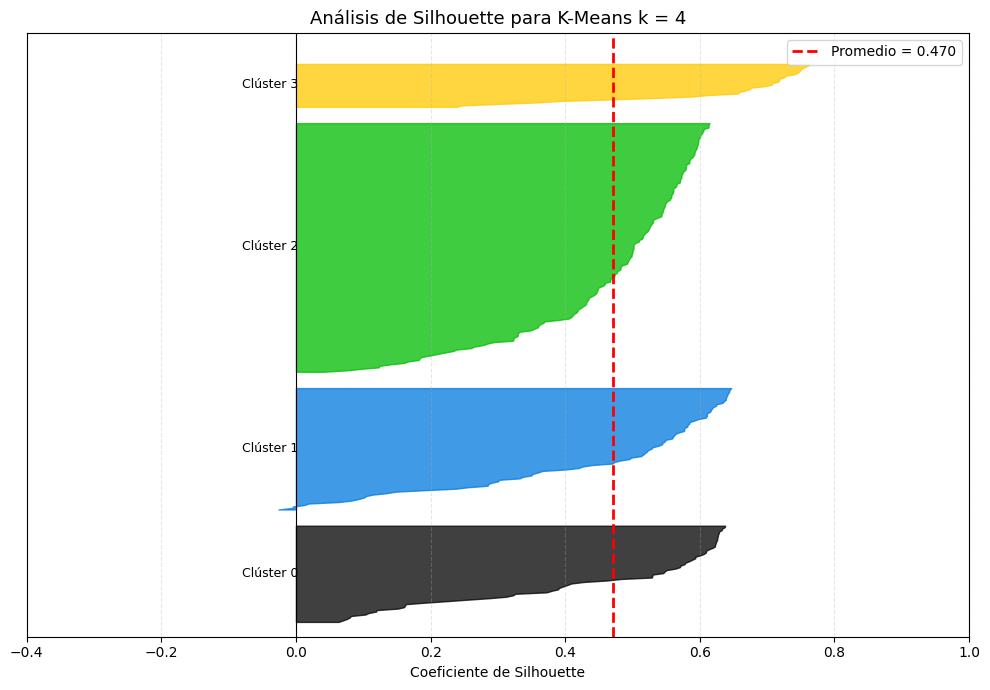

In [89]:
from sklearn.metrics import silhouette_samples

sil_individual = silhouette_samples(
    X_var,
    labels_4
)

fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
k = 4

for grupo in range(k):

    valores_grupo = sil_individual[
        labels_4 == grupo
    ]

    valores_grupo.sort()

    n_grupo = len(valores_grupo)
    y_upper = y_lower + n_grupo

    color = cm.nipy_spectral(
        float(grupo) / k
    )

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        valores_grupo,
        facecolor=color,
        edgecolor=color,
        alpha=0.75
    )

    ax.text(
        -0.08,
        y_lower + n_grupo / 2,
        f"Clúster {grupo}",
        fontsize=9,
        va="center"
    )

    y_lower = y_upper + 10

# Promedio
ax.axvline(
    sil_promedio,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Promedio = {sil_promedio:.3f}"
)

# Referencia en cero
ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xlim(-0.4, 1.0)
ax.set_ylim(0, y_lower + 10)

ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("")
ax.set_yticks([])

ax.set_title(
    "Análisis de Silhouette para K-Means"
    " k = 4",
    fontsize=13
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [72]:
from spopt.region import Skater

In [73]:
from libpysal import weights

# Queen
wq = weights.Queen.from_dataframe(
    gdf,
    ids=gdf["nombre_bar"].tolist()
)

# KNN de 1 vecino
w_knn1 = weights.KNN.from_dataframe(
    gdf,
    k=1,
    ids=gdf["nombre_bar"].tolist()
)

# Unir ambas matrices
wq_conectada = weights.w_union(
    wq,
    w_knn1
)

wq_conectada.transform = "r"

print("Islas:", wq_conectada.islands)
print("Componentes:", wq_conectada.n_components)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: Alejandro Echavarría.
  W.__init__(self, neighbors, ids=ids, **kw)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 92 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Islas: []
Componentes: 1


In [74]:
wq.islands

['Alejandro Echavarría']

In [75]:
model = Skater(
    gdf,
    wq_conectada,
    attrs_name=variables,
    n_clusters=4
)

In [76]:
model.solve()

In [77]:
print("Islas:", wq_conectada.islands)
print("Número de componentes:", wq_conectada.n_components)

Islas: []
Número de componentes: 1


In [78]:
gdf["Region"] = model.labels_

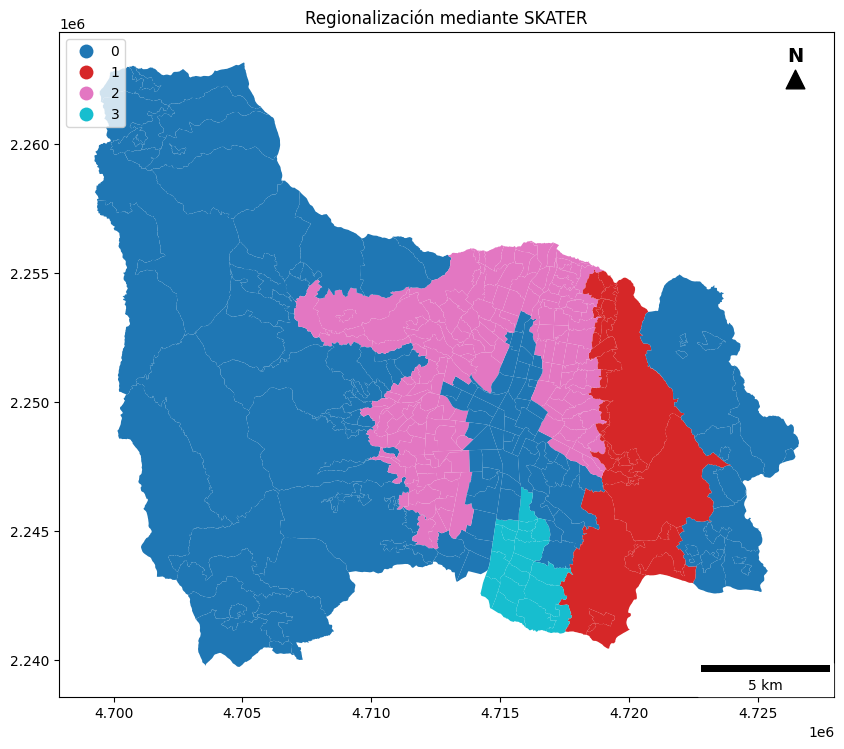

In [88]:
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    column="Region",
    categorical=True,
    cmap="tab10",
    linewidth=0.3,
    legend=True,
    ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower right")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Regionalización mediante SKATER")

plt.show()

In [ ]:
k4sk = gdf.groupby('Region')[variables].mean()
k4sk.T

Region,0,1,2,3
Porc_Artificial,40.356690,53.335444,69.782562,42.390497
Porc_Qca,5.822098,2.442082,92.627542,84.547647
Porc_TPu,0.880142,94.526260,1.651010,0.035870
Pend_mean,16.030476,24.058021,11.652234,10.678991


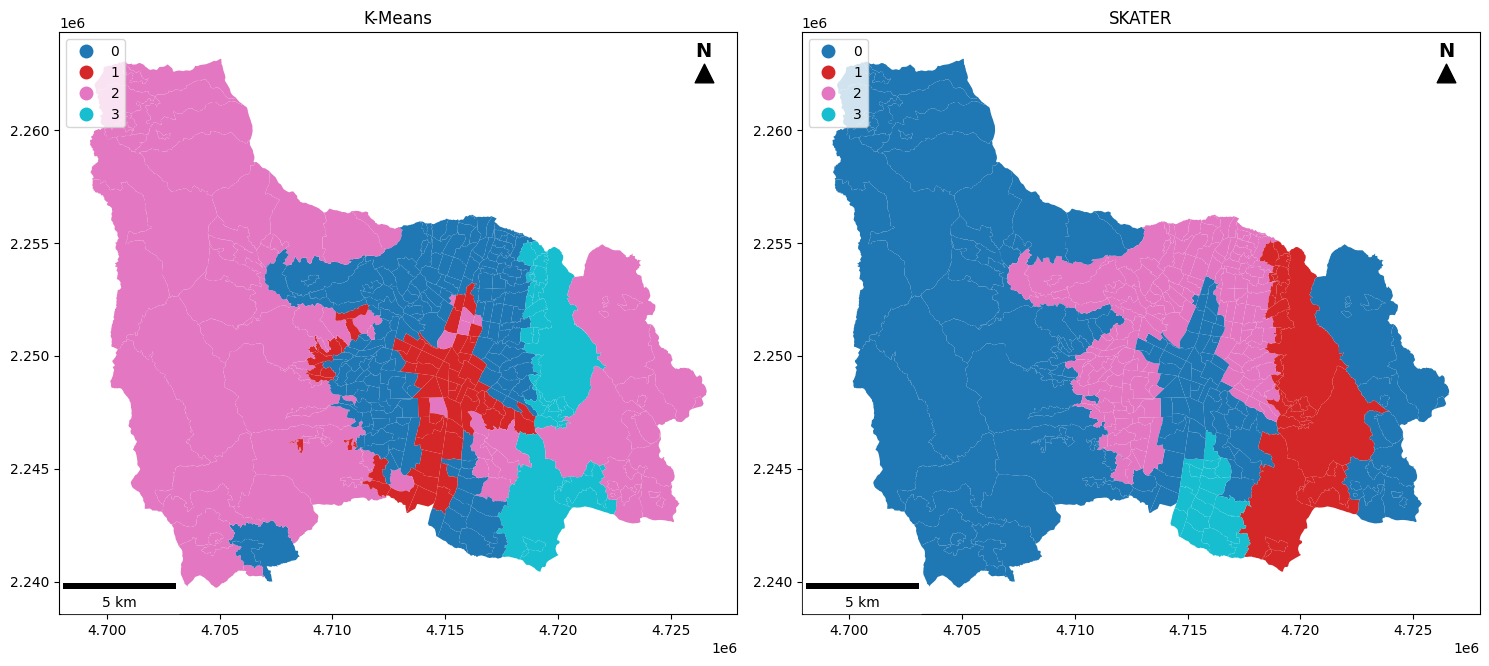

In [87]:
fig, ax = plt.subplots(1,2, figsize=(15,8))

gdf.plot(
    column="k4cls",
    categorical=True,
    cmap="tab10",
    legend=True,
    ax=ax[0])

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax[0].scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax[0].transAxes,
    clip_on=False,
    zorder=10)

ax[0].text(
    0.95,
    0.95,
    "N",
    transform=ax[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax[0].add_artist(scalebar)
ax[0].set_title("K-Means")

gdf.plot(
    column="Region",
    categorical=True,
    cmap="tab10",
    legend=True,
    ax=ax[1])

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax[1].scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax[1].transAxes,
    clip_on=False,
    zorder=10)

ax[1].text(
    0.95,
    0.95,
    "N",
    transform=ax[1].transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax[1].add_artist(scalebar)
ax[1].set_title("SKATER")


plt.tight_layout()
plt.show()